# Notebook 04: Explainability — LIME Local Explanations

**Author:** Facundo Colaccini — PhD Biological Sciences · MSc Biotechnology · Data Science  
**Project:** TB Treatment Dropout Prediction  

---

## Objective

Generate **individual, actionable** explanations for each model prediction using LIME  
(Local Interpretable Model-agnostic Explanations, Ribeiro et al. 2016).

**Why LIME?**  
- Global feature importance (Notebook 03) shows *what matters across all patients*  
- LIME shows *why the model flagged **this specific patient** as high-risk*  
- Actionable for program managers: "Patient X is flagged because of distance + no CHW support"

**Reference:** Ribeiro, M.T. et al. (2016). *Why Should I Trust You?* KDD 2016.


In [1]:
import sys, os, pickle, warnings, importlib.util
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lime
import lime.lime_tabular

from sklearn.model_selection import train_test_split

# Load feature_engineering from source to bypass stale bytecode cache
_fe_path = os.path.abspath('../src/feature_engineering.py')
_spec = importlib.util.spec_from_file_location('feature_engineering', _fe_path)
_fe = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_fe)
sys.modules['feature_engineering'] = _fe

from feature_engineering import prepare_ml_dataset, CATEGORICAL_FEATURES

os.makedirs('../figures', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

print('Imports OK')


Imports OK


## 1. Load Model and Data

In [2]:
with open('../models/rf_tb_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)
with open('../models/optimal_threshold.pkl', 'rb') as f:
    opt = pickle.load(f)

THRESHOLD = opt['threshold']

df = pd.read_csv('../data/processed/ml_dataset.csv')
X, y, _, _, df_ml = prepare_ml_dataset(df, encode_categoricals=True)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_ml.index,
    test_size=0.20, random_state=42, stratify=y
)

print(f'Modelo: {type(model).__name__}')
print(f'Features: {len(feature_names)}')
print(f'Optimal threshold: {THRESHOLD:.2f}')

  Feature matrix: 800 patients x 29 features
    Numeric:      5
    Binary:       11
    Categorical:  13 (encoded)

  Target (dropout_label):
    Defaulted:  157 (19.6%)
    Completed:  643 (80.4%)
Modelo: RandomForestClassifier
Features: 29
Optimal threshold: 0.10


## 2. Configurar LIME Explainer

In [3]:
# Identify categorical features (already encoded) for LIME
from feature_engineering import CATEGORICAL_FEATURES
categorical_feature_indices = [
    i for i, name in enumerate(feature_names)
    if any(name.startswith(cat + '_enc') for cat in CATEGORICAL_FEATURES)
]

# Initialise the LIME explainer
# LIME needs the training set to estimate feature distributions
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=['Completes Tto', 'Dropout'],
    categorical_features=categorical_feature_indices,
    mode='classification',
    random_state=42,
    discretize_continuous=True,  # LIME discretizes continuous features for cleaner natural-language explanations
)

print('LIME Explainer initialised')
print(f'  Categorical features indexed: {len(categorical_feature_indices)}')

LIME Explainer initialised
  Categorical features indexed: 13


## 3. Individual Explanation: High-Risk Patient

Select the test-set patient with the highest predicted dropout probability.

In [4]:
# Predecir probabilidades para el test set
y_prob = model.predict_proba(X_test)[:, 1]

# Case 1: True positive — patient who defaulted and was correctly flagged as high-risk
true_positives_idx = np.where((y_test == 1) & (y_prob >= THRESHOLD))[0]
high_risk_idx = true_positives_idx[np.argmax(y_prob[true_positives_idx])]

instance = X_test[high_risk_idx]
true_label = y_test[high_risk_idx]
predicted_prob = y_prob[high_risk_idx]

print(f'Selected patient: index {high_risk_idx}')
print(f'  True label:       {"DROPOUT" if true_label == 1 else "Completer"}')
print(f'  P(dropout):       {predicted_prob:.3f}')
print(f'  Prediction:       {"HIGH RISK" if predicted_prob >= THRESHOLD else "Low risk"}')

# Compute LIME explanation
print('\nComputing LIME explanation (may take ~30 sec)...')
explanation_tp = explainer.explain_instance(
    data_row=instance,
    predict_fn=model.predict_proba,
    num_features=12,
    num_samples=3000,
)
print('✅ Explanation computed')

Selected patient: index 86
  True label:       DROPOUT
  P(dropout):       0.717
  Prediction:       HIGH RISK

Computing LIME explanation (may take ~30 sec)...
✅ Explanation computed


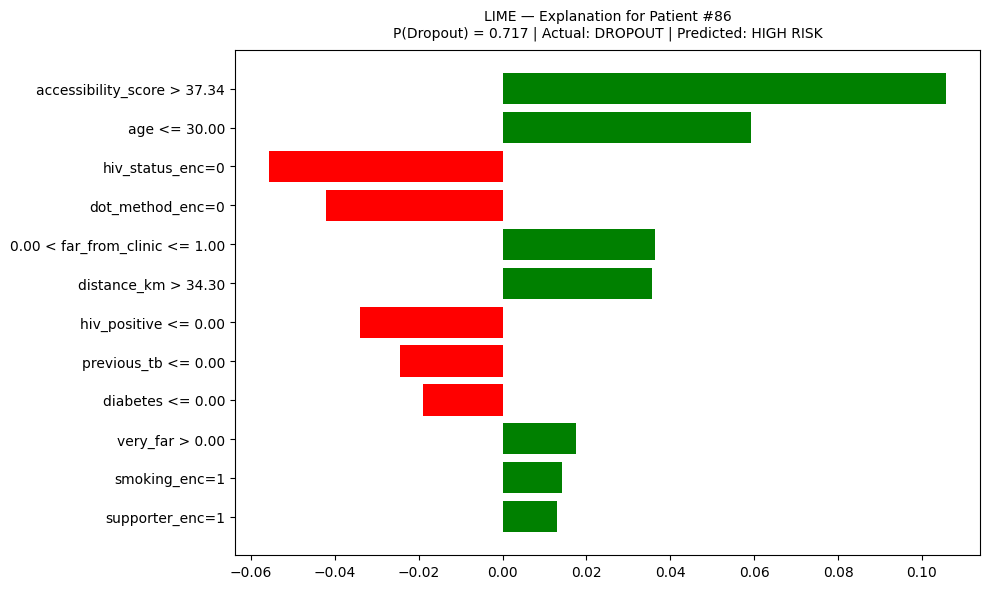


=== TEXT EXPLANATION (for dashboard) ===
Patient #86 — P(dropout) = 0.717

Identified risk factors:
  ⬆ Increases risk: accessibility_score > 37.34 (impacto: +0.106)
  ⬆ Increases risk: age <= 30.00 (impacto: +0.059)
  ⬆ Increases risk: 0.00 < far_from_clinic <= 1.00 (impacto: +0.036)
  ⬆ Increases risk: distance_km > 34.30 (impacto: +0.036)
  ⬆ Increases risk: very_far > 0.00 (impacto: +0.017)
  ⬆ Increases risk: smoking_enc=1 (impacto: +0.014)


In [5]:
# Plot explanation
fig = explanation_tp.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title(f'LIME — Explanation for Patient #{high_risk_idx}\n'
           f'P(Dropout) = {predicted_prob:.3f} | Actual: DROPOUT | '
           f'Predicted: HIGH RISK',
           fontsize=10, pad=10)
plt.tight_layout()
plt.savefig('../figures/11_lime_high_risk_patient.png', dpi=150, bbox_inches='tight')
plt.show()

# Print as text (for dashboard integration)
print('\n=== TEXT EXPLANATION (for dashboard) ===')
print(f'Patient #{high_risk_idx} — P(dropout) = {predicted_prob:.3f}')
print('\nIdentified risk factors:')
for feat, weight in sorted(explanation_tp.as_list(), key=lambda x: x[1], reverse=True)[:6]:
    direction = '⬆ Increases risk' if weight > 0 else '⬇ Reduces risk'
    print(f'  {direction}: {feat} (impacto: {weight:+.3f})')

## 4. Comparison: High-Risk vs. Low-Risk Patient

Computing explanation for low-risk patient (index 110)...


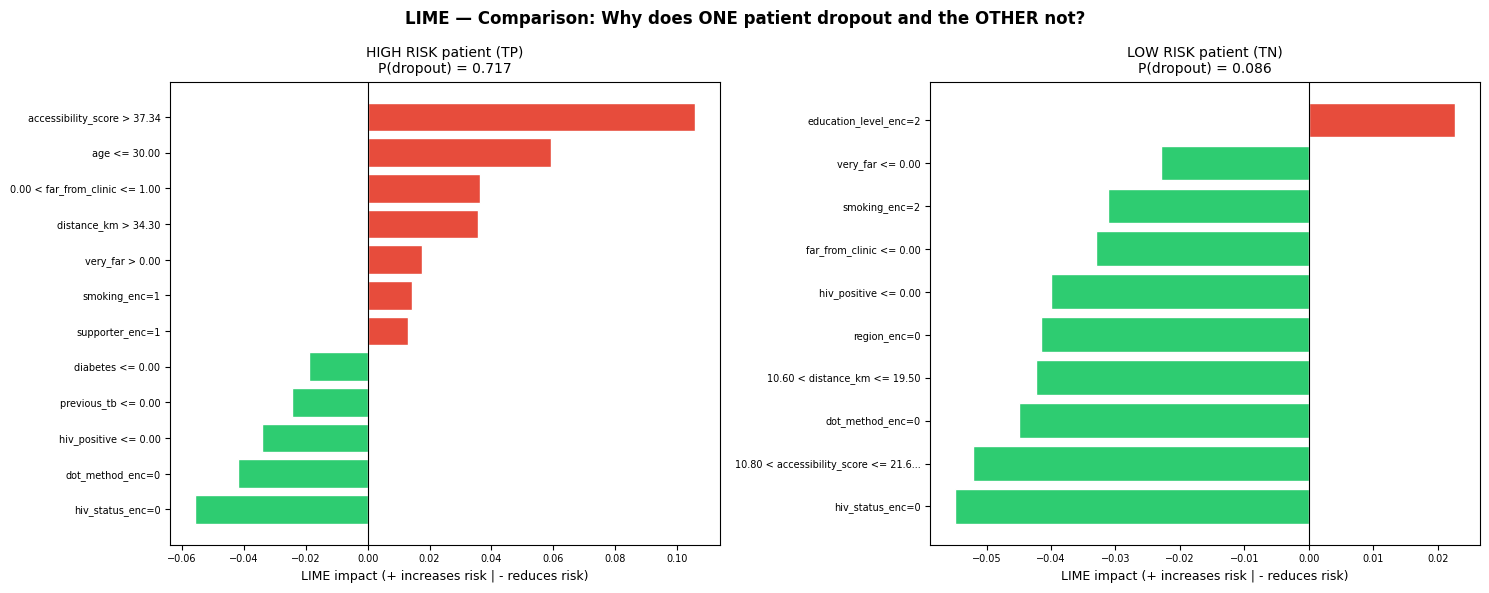

In [6]:
# Case 2: True negative — low-risk patient correctly classified
true_negatives_idx = np.where((y_test == 0) & (y_prob < 0.3))[0]

if len(true_negatives_idx) > 0:
    low_risk_idx = true_negatives_idx[np.argmin(y_prob[true_negatives_idx])]
    instance_lr = X_test[low_risk_idx]
    prob_lr = y_prob[low_risk_idx]

    print(f'Computing explanation for low-risk patient (index {low_risk_idx})...')
    explanation_tn = explainer.explain_instance(
        data_row=instance_lr,
        predict_fn=model.predict_proba,
        num_features=10,
        num_samples=2000,
    )

    # Plot comparativo
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    def plot_lime_horizontal(explanation, ax, title, prob):
        lime_list = sorted(explanation.as_list(), key=lambda x: x[1])
        features = [x[0][:35] + '...' if len(x[0]) > 35 else x[0] for x in lime_list]
        values = [x[1] for x in lime_list]
        colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in values]
        ax.barh(features, values, color=colors, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'{title}\nP(dropout) = {prob:.3f}', fontsize=10)
        ax.set_xlabel('LIME impact (+ increases risk | - reduces risk)', fontsize=9)
        ax.tick_params(labelsize=7)

    plot_lime_horizontal(explanation_tp, ax1, 'HIGH RISK patient (TP)', predicted_prob)
    plot_lime_horizontal(explanation_tn, ax2, 'LOW RISK patient (TN)', prob_lr)

    fig.suptitle('LIME — Comparison: Why does ONE patient dropout and the OTHER not?',
                  fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/12_lime_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Top 10 At-Risk Patients (Dashboard Output)

In [7]:
# Generate Top 10 at-risk patients with their LIME top factor
print('Generating Top 10 high-risk patients with LIME explanations...')
print('(This feeds the risk table in the Streamlit dashboard)')

# Sort by predicted dropout probability
sorted_indices = np.argsort(y_prob)[::-1][:20]  # Top 20 para tener margen

top_patients = []
for i, idx in enumerate(sorted_indices[:10]):
    instance_i = X_test[idx]
    prob_i = y_prob[idx]
    real_i = y_test[idx]

    # LIME explanation (fewer samples for speed)
    exp_i = explainer.explain_instance(
        instance_i, model.predict_proba,
        num_features=3,
        num_samples=500,
    )
    top_factor = sorted(exp_i.as_list(), key=lambda x: abs(x[1]), reverse=True)[0][0]
    # Truncate long factor strings for display
    top_factor = top_factor[:60] + '...' if len(top_factor) > 60 else top_factor

    # Retrieve patient demographic data
    orig_df_idx = idx_test[idx] if hasattr(idx_test, '__getitem__') else i

    risk_tier = 'HIGH' if prob_i >= 0.7 else 'MEDIUM' if prob_i >= 0.5 else 'LOW'

    top_patients.append({
        'Rank': i + 1,
        'patient_id': f'PAT_{idx:04d}',
        'P(Dropout)': round(float(prob_i), 3),
        'Risk': risk_tier,
        'Actual (test)': 'Dropout' if real_i == 1 else 'Completer',
        'Principal Factor': top_factor,
    })

df_top10 = pd.DataFrame(top_patients)
df_top10.to_csv('../reports/top10_high_risk_patients.csv', index=False)

print('\n=== TOP 10 HIGH-RISK PATIENTS ===')
print(df_top10.to_string(index=False))
print('\n✅ Guardado en reports/top10_high_risk_patients.csv')
print('   → Esta tabla se carga en el dashboard de Streamlit')

Generating Top 10 high-risk patients with LIME explanations...
(This feeds the risk table in the Streamlit dashboard)

=== TOP 10 HIGH-RISK PATIENTS ===
 Rank patient_id  P(Dropout)   Risk Actual (test)            Principal Factor
    1   PAT_0007       0.725   HIGH     Completer accessibility_score > 37.34
    2   PAT_0086       0.717   HIGH       Dropout accessibility_score > 37.34
    3   PAT_0062       0.708   HIGH     Completer accessibility_score > 37.34
    4   PAT_0010       0.705   HIGH       Dropout accessibility_score > 37.34
    5   PAT_0050       0.703   HIGH     Completer accessibility_score > 37.34
    6   PAT_0013       0.697 MEDIUM     Completer accessibility_score > 37.34
    7   PAT_0131       0.669 MEDIUM       Dropout accessibility_score > 37.34
    8   PAT_0025       0.669 MEDIUM       Dropout accessibility_score > 37.34
    9   PAT_0064       0.656 MEDIUM       Dropout accessibility_score > 37.34
   10   PAT_0081       0.633 MEDIUM     Completer accessibility_sco

## 6. Save Interactive LIME HTML (for README)

In [8]:
# LIME puede exportar un HTML interactivo (ideal para GitHub Pages)
html_path = '../figures/lime_high_risk_patient.html'
explanation_tp.save_to_file(html_path)

print(f'✅ Interactive explanation saved to: {html_path}')
print('   → Open in browser to view the interactive LIME visualization')
print('   → Include link in GitHub README for maximum impact')

✅ Interactive explanation saved to: ../figures/lime_high_risk_patient.html
   → Open in browser to view the interactive LIME visualization
   → Include link in GitHub README for maximum impact
